In [21]:
import tensorflow as tf
from tensorflow import keras as kr
import matplotlib.pyplot as plt
import numpy as np

In [2]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
tf.__version__

'2.18.0'

In [4]:
tf.test.is_built_with_cuda()

True

In [6]:
(x_train, y_train), (x_test,y_test) = tf.keras.datasets.cifar10.load_data()

In [19]:
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [8]:
def plot_sample(index):
  plt.figure(figsize=(15,2))
  plt.imshow(x_train[index])

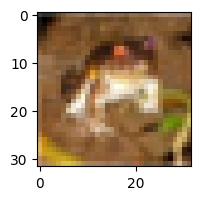

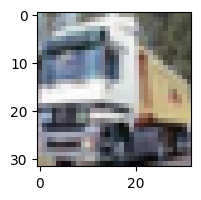

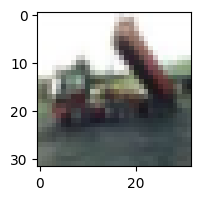

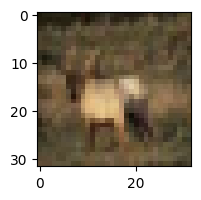

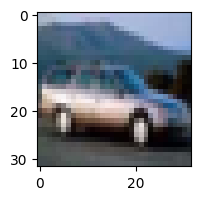

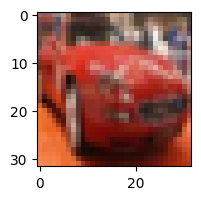

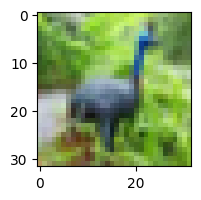

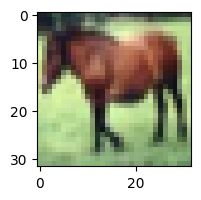

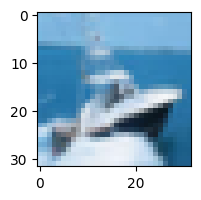

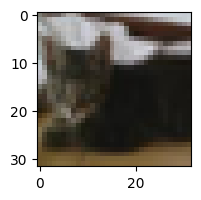

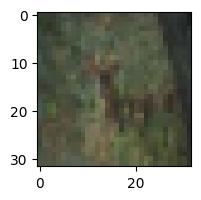

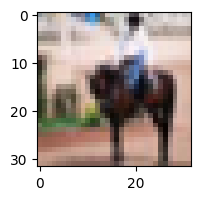

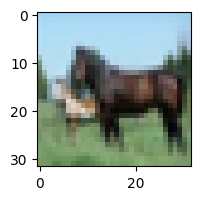

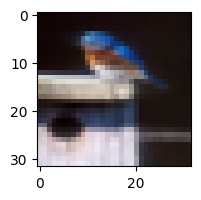

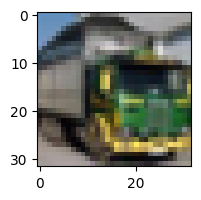

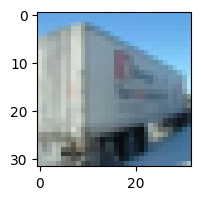

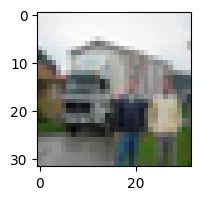

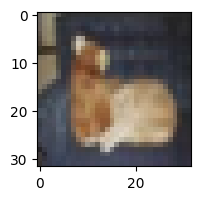

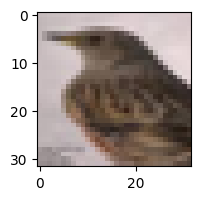

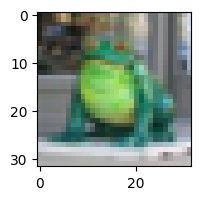

In [9]:
for i in range(20):
  plot_sample(i)

In [10]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [16]:
classes[y_train[15][0]]

'truck'

In [24]:
x_train_scaled = x_train/255
x_test_scaled = x_test/255

In [25]:
y_train_categorical = kr.utils.to_categorical(y_train,10)
y_test_categorical = kr.utils.to_categorical(y_test,10)

In [27]:
model = kr.Sequential([kr.layers.Flatten(input_shape=(32,32,3)),
                       kr.layers.Dense(3000, activation="relu"),
                       kr.layers.Dense(1000, activation="relu"),
                       kr.layers.Dense(10, activation="sigmoid")])
model.compile(optimizer="SGD", loss="categorical_crossentropy", metrics=["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
i = 6
print(classes[np.argmax(model.predict(x_test_scaled)[i])], classes[y_test[i][0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
automobile automobile


In [45]:
model.evaluate(x_test_scaled, y_test_categorical)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1041 - loss: 2.3534


[2.355165958404541, 0.10249999910593033]

In [51]:
def get_model():
    model = kr.Sequential([
            kr.layers.Flatten(input_shape=(32,32,3)),
            kr.layers.Dense(3000, activation='relu'),
            kr.layers.Dense(1000, activation='relu'),
            kr.layers.Dense(500, activation='relu'),
            kr.layers.Dense(250, activation='relu'),
            kr.layers.Dense(100, activation='relu'),
            kr.layers.Dense(10, activation='sigmoid')
        ])

    model.compile(optimizer='SGD',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [52]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(x_train_scaled, y_train_categorical, epochs=1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 84ms/step - accuracy: 0.2749 - loss: 1.9886
2min 14s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [54]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    gpu_model = get_model()
    gpu_model.fit(x_train_scaled, y_train_categorical, epochs=10)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.2842 - loss: 1.9688
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4125 - loss: 1.6493
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4452 - loss: 1.5597
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4679 - loss: 1.4882
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.4916 - loss: 1.4363
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5060 - loss: 1.3855
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5258 - loss: 1.3326
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5354 - loss: 1.3088
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5535 - loss: 1.2491
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5681 - loss: 1.2154
1min 29s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
